In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
from unidecode import unidecode
import geopandas as gpd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp


# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df_merge = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df_location = pd.read_csv('../data/geolocation_clean.csv')
print('데이터 로드 완료')

데이터 로드 완료


In [3]:
df = df_merge.copy()
geo = df_location.copy()

In [4]:
#date 변환 및 극단치 제거 (필요 없으면 삭제)

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [5]:
# #배송 지연 일수 계산 및 극단치 제거 & 지연 여부 (필요 없으면 삭제)


df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df = df[(df['delivery_delay_days'] > 0) & (df['delivery_delay_days'] < 100)]
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

In [6]:
#지연 일수별 평균 리뷰 스코어

avg_score = df.groupby('delivery_delay_days')['review_score'].mean()

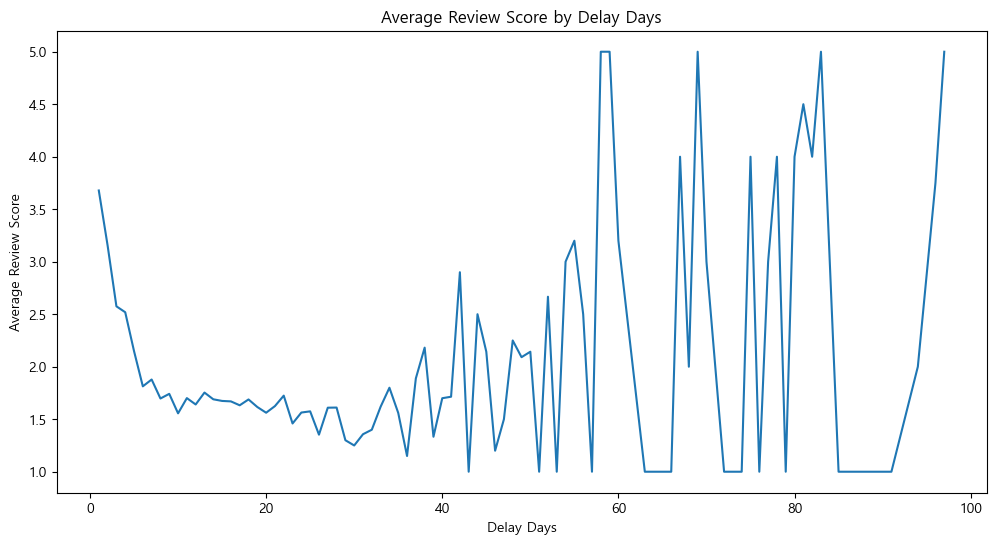

In [7]:
# #지연 일수별 평균 스코어 시각화 (필요 없으면 삭제)

plt.plot(avg_score.index, avg_score.values)
plt.xlabel("Delay Days")
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Delay Days")
plt.show()

In [8]:
buyer_delay = df.groupby('customer_state')['delivery_delay_days'].mean().sort_values(ascending=False)

seller_delay = df.groupby('seller_state')['delivery_delay_days'].mean().sort_values(ascending=False)

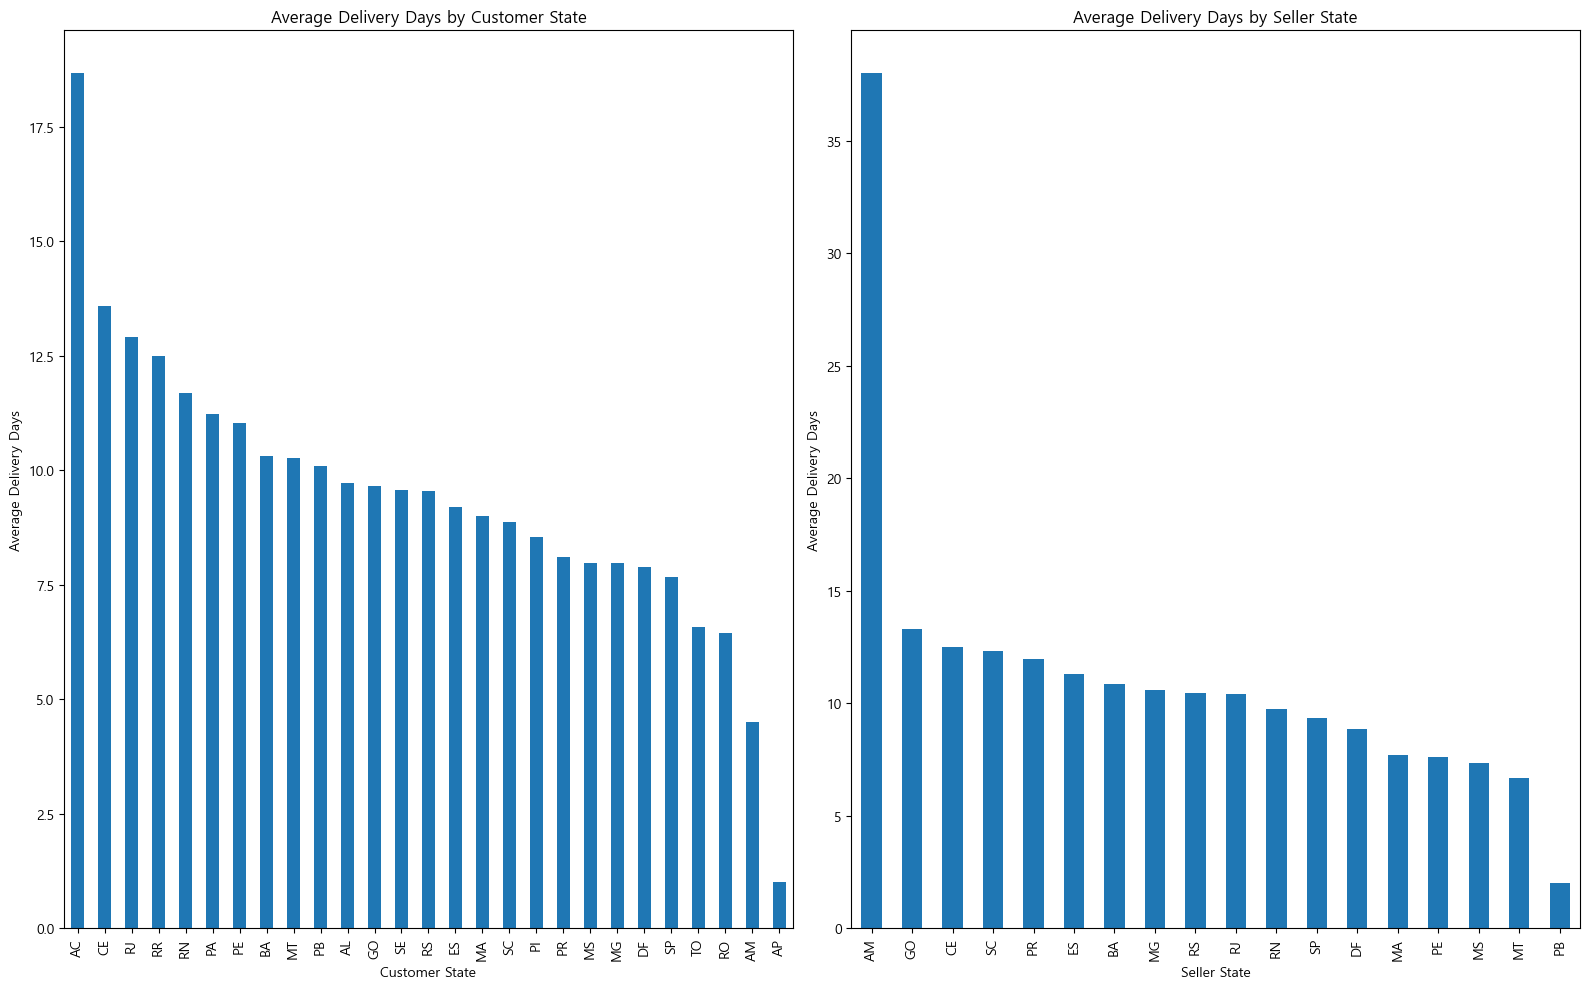

In [9]:
# #구매자와 판매자의 평균 지연 일수 시각화(필요 없으면 삭제)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

buyer_delay.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel("Customer State")
axes[0].set_ylabel("Average Delivery Days")
axes[0].set_title("Average Delivery Days by Customer State")

seller_delay.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel("Seller State")
axes[1].set_ylabel("Average Delivery Days")
axes[1].set_title("Average Delivery Days by Seller State")

plt.tight_layout()
plt.show()

In [10]:
# # 1. 판매자 state별 평균 배송 지연 (sort로 보기만 한 거, 필요 없으면 삭제)

# print(seller_delay)

In [11]:
# # 2. 구매자 state별 평균 배송 지연 (sort로 보기만 한 거, 필요 없으면 삭제)
# print(buyer_delay)


In [12]:
# 3. 판매자 + 구매자 state 조합별 평균 배송 지연
combo_delay = df.groupby(['seller_state', 'customer_state'])['delivery_delay_days'].mean().reset_index()
combo_delay = combo_delay.sort_values('delivery_delay_days', ascending=False)
print(combo_delay.head(20))
combo_delay.shape

    seller_state customer_state  delivery_delay_days
0             AM             AL            38.000000
166           SC             GO            32.500000
42            GO             RJ            31.333333
78            MG             PI            31.000000
33            ES             PA            25.000000
1             BA             AC            24.000000
164           SC             CE            23.500000
163           SC             BA            23.444444
16            CE             RJ            23.000000
151           RS             DF            22.000000
56            MA             PB            22.000000
17            DF             BA            22.000000
138           RJ             RN            21.333333
146           RN             CE            20.000000
18            DF             CE            18.500000
133           RJ             PA            18.000000
126           RJ             DF            17.750000
70            MG             GO            17.

(209, 3)

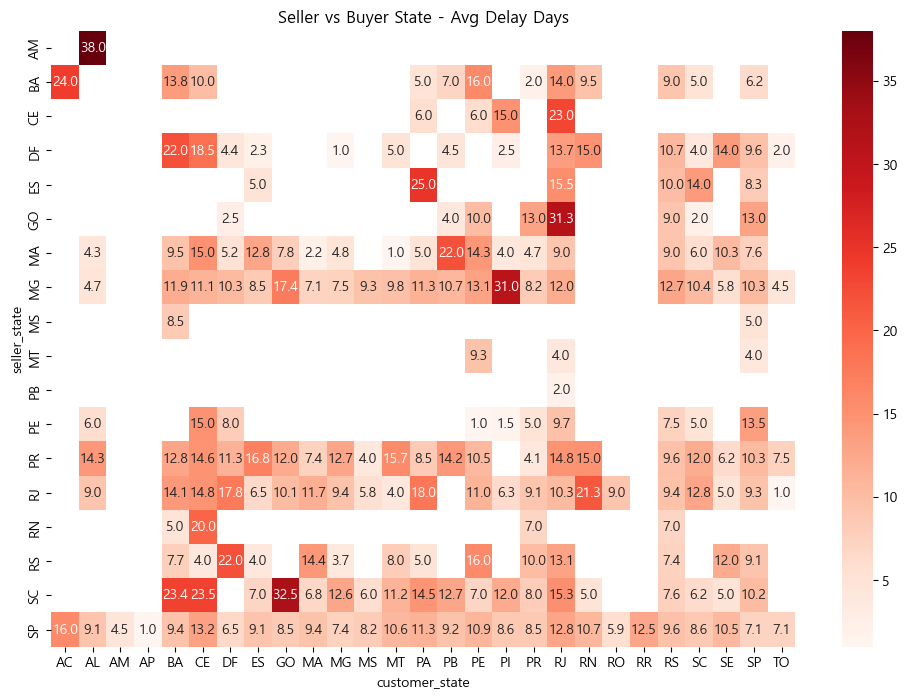

In [13]:
# 히트맵 - 조합별 지연일수 한눈에 보기
pivot = combo_delay.pivot(index='seller_state', columns='customer_state', values='delivery_delay_days')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Seller vs Buyer State - Avg Delay Days')
plt.show()

In [14]:
groups = [group['delivery_delay_days'].values for _, group in df.groupby(['seller_state', 'customer_state'])]

# 정규성 검정 (Shapiro-Wilk)
stat_s, p_s = shapiro(df['delivery_delay_days'])
print(f'정규성 p-value: {p_s:.20f}') 

# 등분산성 검정 (Levene)
stat_l, p_l = levene(*groups)
print(f'등분산성 p-value: {p_l:.10f}')

#정규성 p-value=0 -> 분포 자체가 너무 비정규적이기 때문에 이러한 값이 나옴 문제 없음
#정규성 < 0.05 -> 정규성 불만족
#등분산성 p-value=0.000023
#등분산성 불충족

# 정규성 x, 등분산성 x -> kruskal-wallis(KW) 사용

정규성 p-value: 0.00000000000000000000
등분산성 p-value: 0.0000000000


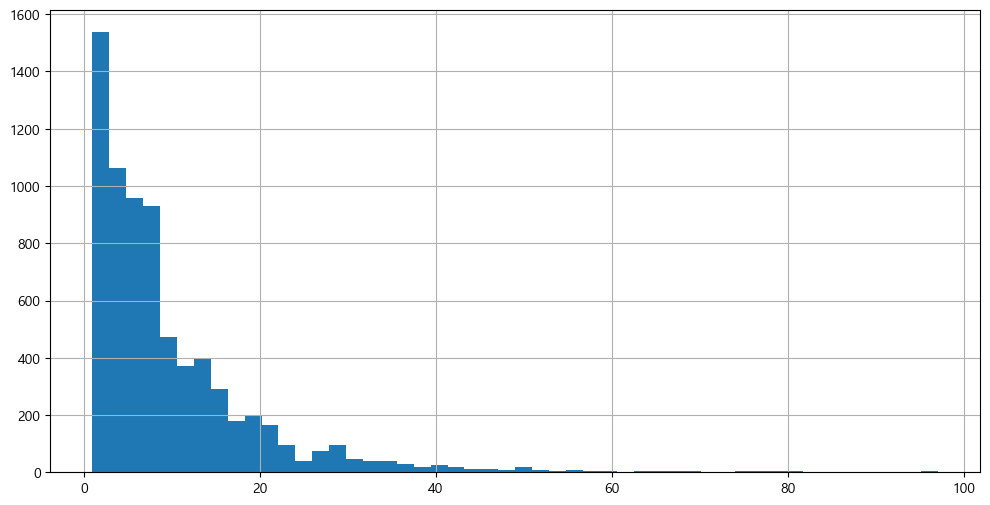

In [15]:
#지연일수 분포
df['delivery_delay_days'].hist(bins=50)
plt.show()

In [16]:
# TODO: Kruskal-Wallis 검정 수행 (stats.kruskal)

stat_kw, p_kw = stats.kruskal(*groups)
print(f"  H 통계량: {stat_kw:.4f}")
print(f"  p-value: {p_kw:.20f}")

# TODO: η²_H 효과크기 계산
# 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
k = 209
N = 7211
eta_sq_h = (stat_kw - k + 1) / (N - k)

print(f"효과 크기: {eta_sq_h}")

#p값 < 0.05 -> 유의미함
#효과 크기: 0.06 -> 중간 효과

  H 통계량: 667.5257
  p-value: 0.00000000000000000000
효과 크기: 0.06562778170190738


In [17]:

# 같은 state 여부 변수 생성
df['same_state_str'] = df['seller_state'] == df['customer_state']

same = df[df['same_state_str']]['delivery_delay_days']
diff = df[~df['same_state_str']]['delivery_delay_days']

stat, p = mannwhitneyu(same, diff, alternative='two-sided')

print("Mann-Whitney U:", stat)
print("p-value:", p)

print("같은 state 평균:", same.mean())
print("다른 state 평균:", diff.mean())

#p: 0에 매우 가까움 -> 귀무가설 기각
#"같은 도시일 때와 다른 도시일 때 차이가 있다"라는 가설을 입증

Mann-Whitney U: 3546499.0
p-value: 1.1258266405576404e-61
같은 state 평균: 7.1610890527509925
다른 state 평균: 10.555066079295154


In [18]:
#구매자-판매자 주 컬럼 생성

df['state_pair'] = df['seller_state'] + "_" + df['customer_state']

pair_count = df['state_pair'].value_counts()
valid_pairs = pair_count[pair_count >= 30].index

df_pair_filtered = df[df['state_pair'].isin(valid_pairs)]

In [19]:
#구매자-판매자 주 조합과 지연일로 통계검정

groups2 = [
    group['delivery_delay_days'].values
    for name, group in df_pair_filtered.groupby('state_pair')
]

stat, p = kruskal(*groups2)

print("Kruskal H:", stat)
print("p-value:", p)

#p=0 -> 귀무가설 기각

Kruskal H: 460.8628732960803
p-value: 1.886333980174936e-77


In [20]:
#dunn test

dunn_result = sp.posthoc_dunn(
    df_pair_filtered,
    val_col='delivery_delay_days',
    group_col='state_pair',
    p_adjust='fdr_bh'
)

#display(dunn_result)
#도표 너무 커서 주석처리

In [21]:
#dunn test 결과 p < 0.05만 나옴&중복 제거되도록 필터링

sig_pairs = (
    dunn_result
    .stack()
    .reset_index()
)

sig_pairs.columns = ['pair1', 'pair2', 'p_value']

sig_pairs = sig_pairs[
    (sig_pairs['pair1'] < sig_pairs['pair2']) &
    (sig_pairs['p_value'] < 0.05)
]

sig_pairs = sig_pairs.sort_values('p_value')

print(sig_pairs)

     pair1  pair2       p_value
923  SP_RJ  SP_SP  3.769316e-72
654  SP_MG  SP_RJ  2.398981e-19
197  PR_RJ  SP_SP  6.239399e-15
494  SP_CE  SP_SP  6.004628e-13
989  SP_RS  SP_SP  6.423143e-10
..     ...    ...           ...
455  SP_BA  SP_PR  4.286565e-02
411  SP_AL  SP_DF  4.286565e-02
121  MG_SP  SP_PA  4.286565e-02
648  SP_MG  SP_MT  4.574513e-02
55   MG_MG  SP_PA  4.803392e-02

[102 rows x 3 columns]


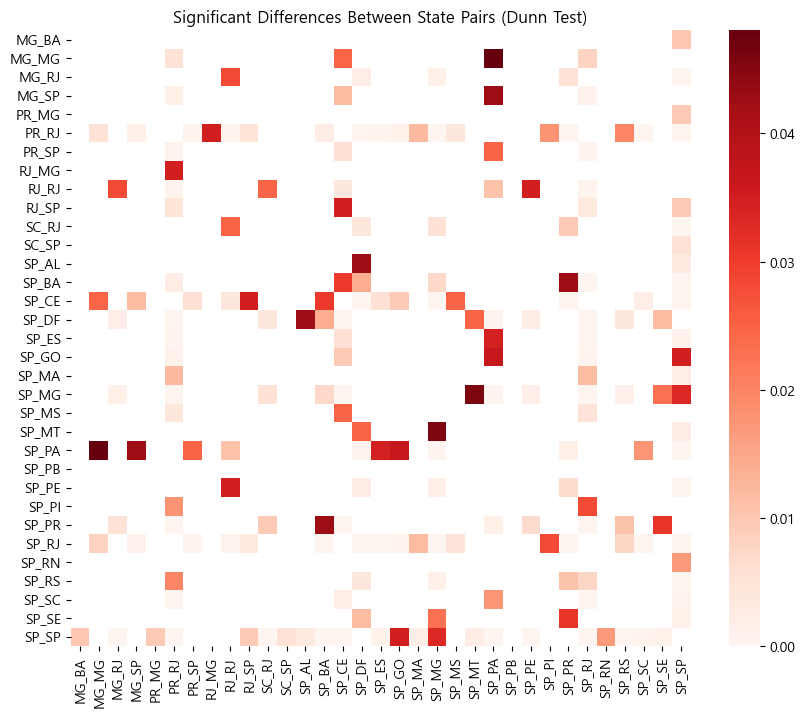

In [22]:
#이를 시각화

sig_matrix = dunn_result.copy()

# 유의하지 않은 값 제거
sig_matrix[sig_matrix >= 0.05] = np.nan

plt.figure(figsize=(10,8))

sns.heatmap(
    sig_matrix,
    annot=False,
    cmap="Reds",
    mask=sig_matrix.isna()
)

plt.title("Significant Differences Between State Pairs (Dunn Test)")
plt.show()